In [430]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore') 
print("Libraries imported.")

Libraries imported.


In [431]:
from pathlib import Path
import os

data_path = Path('Dataset') / 'weatherdata.csv'
print("Working directory:", os.getcwd())
print("Looking for file:", data_path.resolve())

if not data_path.exists():
    raise FileNotFoundError(f"File not found: {data_path.resolve()} - check the path or working directory.")

try:
    df = pd.read_csv(data_path)
    print("Data loaded.")
    print("First 5 rows of the dataset:")
    print(df.head())
except OSError as e:
    # common fallback: try a different encoding/engine
    print("OSError while reading CSV:", e)
    try:
        df = pd.read_csv(data_path, encoding='latin-1', engine='python')
        print("Data loaded with fallback encoding/engine.")
        print(df.head())
    except Exception as e2:
        print("Fallback failed:", e2)
        raise


Working directory: p:\flight-delay-prediction-project
Looking for file: P:\flight-delay-prediction-project\Dataset\weatherdata.csv
Data loaded.
First 5 rows of the dataset:
  country location_name          region  latitude  longitude      timezone  \
0   India    Ashoknagar  Madhya Pradesh     24.57      77.72  Asia/Kolkata   
1   India        Raisen  Madhya Pradesh     23.33      77.80  Asia/Kolkata   
2   India    Chhindwara  Madhya Pradesh     22.07      78.93  Asia/Kolkata   
3   India         Betul  Madhya Pradesh     21.86      77.93  Asia/Kolkata   
4   India   Hoshangabad  Madhya Pradesh     22.75      77.72  Asia/Kolkata   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1693286100  2023-08-29 10:45                 27.5   
1          1693286100  2023-08-29 10:45                 27.5   
2          1693286100  2023-08-29 10:45                 26.3   
3          1693286100  2023-08-29 10:45                 25.6   
4          1693286100  2023-08-29 10:4

In [432]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118298 entries, 0 to 118297
Data columns (total 42 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       118298 non-null  str    
 1   location_name                 118298 non-null  str    
 2   region                        118298 non-null  str    
 3   latitude                      118298 non-null  float64
 4   longitude                     118298 non-null  float64
 5   timezone                      118298 non-null  str    
 6   last_updated_epoch            118298 non-null  int64  
 7   last_updated                  118298 non-null  str    
 8   temperature_celsius           118298 non-null  float64
 9   temperature_fahrenheit        118298 non-null  float64
 10  condition_text                118298 non-null  str    
 11  wind_mph                      118298 non-null  float64
 12  wind_kph                      118298 non-null  float64


In [433]:
df.shape

(118298, 42)

In [434]:
df.columns

Index(['country', 'location_name', 'region', 'latitude', 'longitude',
       'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')

In [435]:
weather = df[
    [
        'temperature_celsius',
        'humidity',
        'wind_kph',
        'gust_kph',
        'visibility_km',
        'precip_mm',
        'pressure_mb',
        'condition_text'
    ]
]

In [436]:
weather.isnull().sum()

temperature_celsius    0
humidity               0
wind_kph               0
gust_kph               0
visibility_km          0
precip_mm              0
pressure_mb            0
condition_text         0
dtype: int64

In [437]:
weather['condition_text'].value_counts()

condition_text
Clear                                          47313
Clear                                          23794
Mist                                           16839
Partly cloudy                                   9294
Patchy rain possible                            5126
Light rain shower                               2925
Partly Cloudy                                   2178
Fog                                             2017
Overcast                                        1868
Cloudy                                          1378
Patchy rain nearby                              1341
Sunny                                            772
Light rain                                       497
Moderate or heavy rain shower                    404
Overcast                                         334
Light drizzle                                    271
Cloudy                                           255
Moderate or heavy rain with thunder              239
Patchy light drizzle           

In [438]:
weather['condition_text'].unique()

<ArrowStringArray>
[                              'Partly cloudy',
                                       'Sunny',
                                      'Cloudy',
                                        'Mist',
                        'Patchy rain possible',
                                    'Overcast',
              'Patchy light rain with thunder',
                           'Light rain shower',
               'Moderate or heavy rain shower',
                                       'Clear',
                                  'Light rain',
                      'Torrential rain shower',
                                         'Fog',
                 'Thundery outbreaks possible',
                        'Patchy light drizzle',
                               'Moderate rain',
                           'Patchy light rain',
                      'Moderate rain at times',
                                  'Heavy rain',
                         'Heavy rain at times',
                     

In [439]:
weather['condition_text'] = weather['condition_text'].str.lower().str.strip()

In [440]:
weather_map = {

# CLEAR
'clear': 'Clear',
'sunny': 'Clear',

# CLOUDY
'partly cloudy': 'Cloudy',
'cloudy': 'Cloudy',
'overcast': 'Cloudy',
'partly cloudy ': 'Cloudy',

# LOW VISIBILITY
'mist': 'LowVisibility',
'fog': 'LowVisibility',

# LIGHT RAIN
'patchy rain possible': 'LightRain',
'light rain shower': 'LightRain',
'light rain': 'LightRain',
'patchy light drizzle': 'LightRain',
'patchy light rain': 'LightRain',
'light drizzle': 'LightRain',
'patchy rain nearby': 'LightRain',

# HEAVY RAIN
'moderate rain': 'HeavyRain',
'moderate rain at times': 'HeavyRain',
'heavy rain': 'HeavyRain',
'heavy rain at times': 'HeavyRain',
'moderate or heavy rain shower': 'HeavyRain',

# STORM / THUNDER
'patchy light rain with thunder': 'Storm',
'thundery outbreaks possible': 'Storm',
'torrential rain shower': 'Storm',
'moderate or heavy rain with thunder': 'Storm',
'thundery outbreaks in nearby': 'Storm',
'patchy light rain in area with thunder': 'Storm',
'moderate or heavy rain in area with thunder': 'Storm',

# SNOW / ICE
'patchy snow possible': 'Snow',
'moderate or heavy snow showers': 'Snow',
'light snow showers': 'Snow',
'moderate or heavy snow with thunder': 'Snow',
'patchy light snow with thunder': 'Snow',
'light sleet': 'Snow',
'light freezing rain': 'Snow',
'patchy light snow': 'Snow',
'patchy moderate snow': 'Snow',
'light snow': 'Snow',
'moderate snow': 'Snow',
'heavy snow': 'Snow',
'patchy heavy snow': 'Snow',
'patchy snow nearby': 'Snow',
'patchy sleet nearby': 'Snow',
'moderate or heavy sleet': 'Snow',
'light sleet showers': 'Snow',
'patchy light snow in area with thunder': 'Snow',
'moderate or heavy snow in area with thunder': 'Snow',

# DEFAULT FALLBACK
}

In [441]:
weather['WeatherGroup'] = weather['condition_text'].map(weather_map)

In [442]:
weather['WeatherGroup'] = weather['WeatherGroup'].fillna('Cloudy')

In [443]:
weather['WeatherGroup'].value_counts()

WeatherGroup
Clear            71879
LowVisibility    18856
Cloudy           15415
LightRain        10543
HeavyRain          738
Storm              538
Snow               329
Name: count, dtype: int64

In [444]:
weather.sample(5)

,temperature_celsius,humidity,wind_kph,gust_kph,visibility_km,precip_mm,pressure_mb,condition_text,WeatherGroup
31803,6.6,44,3.6,6.8,10.0,0.0,1021.0,clear,Clear
75967,23.7,85,12.2,23.2,10.0,0.0,1013.0,partly cloudy,Cloudy
25114,24.1,54,5.4,11.3,10.0,0.0,1011.0,clear,Clear
29405,22.1,47,7.2,15.1,10.0,0.0,1014.0,clear,Clear
60952,16.2,51,6.1,12.9,10.0,0.0,1017.0,cloudy,Cloudy


In [445]:
weather['WeatherGroup'] = weather['WeatherGroup'].str.lower().str.strip()

In [446]:
def weather_risk(row):

    # EXTREME
    if (
        row['WeatherGroup'] in ['storm', 'snow', 'heavy rain', 'lowvisibility']
        or row['temperature_celsius'] < -10
        or row['temperature_celsius'] > 40
        or row['humidity'] > 90
        or row['visibility_km'] < 3
        or row['wind_kph'] > 45
        or row['gust_kph'] > 40
        or row['precip_mm'] > 8
        or row['pressure_mb'] < 970
        or row['pressure_mb'] > 1030
    ):
        return 'Extreme'

    # MODERATE
    elif (
        row['WeatherGroup'] in ['cloudy', 'light rain']
        or (30 <= row['temperature_celsius'] <= 40)
        or (70 <= row['humidity'] <= 90)
        or (3 <= row['visibility_km'] <= 7)
        or (25 <= row['wind_kph'] <= 45)
        or (30 <= row['gust_kph'] <= 40)
        or (3 <= row['precip_mm'] <= 8)
    ):
        return 'Moderate'

    # NORMAL
    else:
        return 'Normal'
    
weather['WeatherRisk'] = weather.apply(weather_risk, axis=1)

In [447]:
weather['WeatherRisk'].value_counts()

WeatherRisk
Normal      51295
Moderate    38432
Extreme     28571
Name: count, dtype: int64

In [448]:
weather[['condition_text','WeatherRisk']].head()

,condition_text,WeatherRisk
0,partly cloudy,Moderate
1,sunny,Moderate
2,partly cloudy,Moderate
3,cloudy,Moderate
4,cloudy,Moderate


In [449]:
newdf = weather.copy()

In [450]:
y = weather['WeatherRisk']

In [451]:
features = [
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'gust_kph',
    'visibility_km',
    'precip_mm',
    'pressure_mb'
]

X = newdf[features]

In [452]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [453]:
X.shape, y.shape

((118298, 7), (118298,))

In [454]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [455]:
from xgboost import XGBClassifier

weather_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

weather_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

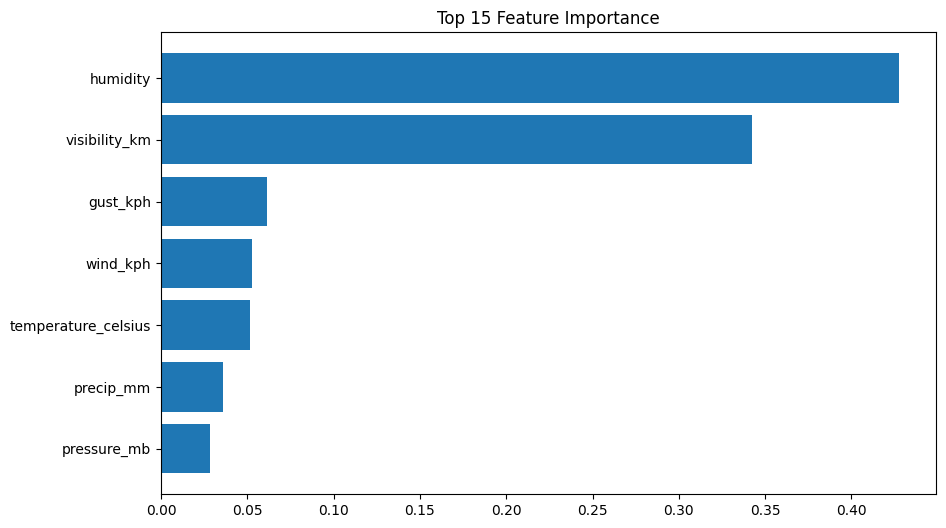

In [456]:
import matplotlib.pyplot as plt
import pandas as pd

# Get importance
importances =weather_model.feature_importances_
features = X.columns

# Create dataframe
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
})

# Sort and take top 15
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance")
plt.show()

In [457]:
y_pred = weather_model.predict(X_test)
y_prob = weather_model.predict_proba(X_test)[:,1]

In [458]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9457311918850381

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      5658
           1       0.99      0.84      0.91      7851
           2       0.90      1.00      0.95     10151

    accuracy                           0.95     23660
   macro avg       0.96      0.94      0.95     23660
weighted avg       0.95      0.95      0.94     23660


Confusion Matrix:
 [[ 5601    43    14]
 [  116  6628  1107]
 [    1     3 10147]]


In [459]:
import pickle

with open('weather_model.pkl', 'wb') as f:
    pickle.dump(weather_model, f)

with open('weather_columns.pkl', 'wb') as f:
    pickle.dump(X.columns, f)